In [54]:
# 1.导入库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import rcParams
from matplotlib.pyplot import title

rcParams['font.sans-serif'] = ['SimHei']


In [ ]:
# 2.导入数据
df = pd.read_csv('D:/jupyter学习/.venv/house_sales.csv')

In [56]:
# 3.数据概览
print("总记录数：",len(df))
print('字段数量：',len(df.columns))
df.head(5)

总记录数： 106118
字段数量： 12


,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm


In [57]:
# 4.数据清洗
# 删除无用数据'origin_url'
df.drop(columns = '=origin_url', inplace=True)

KeyError: "['=origin_url'] not found in axis"

In [58]:
# 检测是否有缺失值
df.isna().sum()
# 删除缺失值
df.dropna(inplace=True)
# 检查删除后的记录数
print(len(df))

57520


In [59]:
# 检查是否有重复值
df.duplicated().sum()
# 删除重复数据
df.drop_duplicates(inplace=True)

In [60]:
print(len(df))

28379


In [61]:
# 面积的数据的替换
df['area'] = df['area'].str.replace('㎡','').astype(float)

In [62]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46万,安徽,2室1厅,南向,9200元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_398859799.htm
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158万,安徽,4室2厅,南向,13167元/㎡,2012年建,https://hf.esf.fang.com/chushou/3_381138154.htm


In [63]:
# 价格数据的转换
df['price'] = df['price'].str.replace('万','').astype(float)

In [64]:
# 转换'unit'数据
df['unit'] = df['unit'].astype(str).str.replace('元/㎡','').astype(float)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019年建,https://hf.esf.fang.com/chushou/3_398859799.htm
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012年建,https://hf.esf.fang.com/chushou/3_381138154.htm


In [65]:
# 年份数据类型的转换
df['year'] = df['year'].str.replace('年建','').astype(float)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013.0,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019.0,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017.0,https://hf.esf.fang.com/chushou/3_404372096.htm
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019.0,https://hf.esf.fang.com/chushou/3_398859799.htm
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012.0,https://hf.esf.fang.com/chushou/3_381138154.htm


In [66]:
# 把朝向数据的数据类型改为分类类型
df['toward'].value_counts()
df['toward'] = df['toward'].astype('category')
df.info()

<class 'pandas.DataFrame'>
Index: 28379 entries, 0 to 106088
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   city        28379 non-null  str     
 1   address     28379 non-null  str     
 2   area        28379 non-null  float64 
 3   floor       28379 non-null  str     
 4   name        28379 non-null  str     
 5   price       28379 non-null  float64 
 6   province    28379 non-null  str     
 7   rooms       28379 non-null  str     
 8   toward      28379 non-null  category
 9   unit        28379 non-null  float64 
 10  year        28379 non-null  float64 
 11  origin_url  28379 non-null  str     
dtypes: category(1), float64(4), str(7)
memory usage: 2.6 MB


In [67]:
# 占地面积异常值处理
df = df[(df['area  ']<600)&(df['area']>20)]

KeyError: 'area  '

In [68]:
# 房屋异常值处理
Q1 = df['price'].quantile(q=0.25)
Q3 = df['price'].quantile(q=0.75)
IQR = Q3 - Q1
lower_prices  = Q1 - 1.5 * IQR
high_prices = Q1 + 1.5*IQR
df = df[(df['price']<high_prices)&(df['price']>lower_prices)]

In [69]:
df.head()
len(df)

23954

In [70]:
# 新数据特征的构造
# 构造一个distinct特征
df.head()
df['distinct'] = df['address'].str.split('-').str[0]
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url,distinct
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013.0,https://hf.esf.fang.com/chushou/3_404230646.htm,龙岗
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019.0,https://hf.esf.fang.com/chushou/3_404304901.htm,生态公园
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017.0,https://hf.esf.fang.com/chushou/3_404372096.htm,撮镇
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019.0,https://hf.esf.fang.com/chushou/3_398859799.htm,龙岗
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012.0,https://hf.esf.fang.com/chushou/3_381138154.htm,新亚汽车站


In [71]:
# 楼层的类型floor_type
def fun1(str1):
    if pd.isna(str1):
        return '未知'
    elif '低' in str1:
        return '低楼层'
    elif '中' in str1:
        return '中楼层'
    elif '高' in str1:
        return '高楼层'
    else:
        return '未知'

df['floor_type'] = df['floor'].apply(fun1).astype('category')
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url,distinct,floor_type
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013.0,https://hf.esf.fang.com/chushou/3_404230646.htm,龙岗,中楼层
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019.0,https://hf.esf.fang.com/chushou/3_404304901.htm,生态公园,中楼层
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017.0,https://hf.esf.fang.com/chushou/3_404372096.htm,撮镇,中楼层
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019.0,https://hf.esf.fang.com/chushou/3_398859799.htm,龙岗,高楼层
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012.0,https://hf.esf.fang.com/chushou/3_381138154.htm,新亚汽车站,中楼层


In [72]:

# 判断是否为直辖市
df['zxs'] = df['city'].apply(lambda x: True if x in ['北京','上海','天津','重庆'] else False)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url,distinct,floor_type,zxs
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013.0,https://hf.esf.fang.com/chushou/3_404230646.htm,龙岗,中楼层,False
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019.0,https://hf.esf.fang.com/chushou/3_404304901.htm,生态公园,中楼层,False
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017.0,https://hf.esf.fang.com/chushou/3_404372096.htm,撮镇,中楼层,False
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019.0,https://hf.esf.fang.com/chushou/3_398859799.htm,龙岗,高楼层,False
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012.0,https://hf.esf.fang.com/chushou/3_381138154.htm,新亚汽车站,中楼层,False


In [73]:
# 把'室'和'厅'的数据转换出来
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)
df['livingroom'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url,distinct,floor_type,zxs,bedrooms,livingroom
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013.0,https://hf.esf.fang.com/chushou/3_404230646.htm,龙岗,中楼层,False,3,2
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019.0,https://hf.esf.fang.com/chushou/3_404304901.htm,生态公园,中楼层,False,3,2
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017.0,https://hf.esf.fang.com/chushou/3_404372096.htm,撮镇,中楼层,False,2,1
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019.0,https://hf.esf.fang.com/chushou/3_398859799.htm,龙岗,高楼层,False,2,1
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012.0,https://hf.esf.fang.com/chushou/3_381138154.htm,新亚汽车站,中楼层,False,4,2


In [74]:
# 把价格进行分段
df['price_labels'] = pd.cut(df['price'],bins = 4,labels = ['低价','中价','高价','豪华'])
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url,distinct,floor_type,zxs,bedrooms,livingroom,price_labels
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013.0,https://hf.esf.fang.com/chushou/3_404230646.htm,龙岗,中楼层,False,3,2,高价
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019.0,https://hf.esf.fang.com/chushou/3_404304901.htm,生态公园,中楼层,False,3,2,高价
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017.0,https://hf.esf.fang.com/chushou/3_404372096.htm,撮镇,中楼层,False,2,1,低价
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019.0,https://hf.esf.fang.com/chushou/3_398859799.htm,龙岗,高楼层,False,2,1,低价
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012.0,https://hf.esf.fang.com/chushou/3_381138154.htm,新亚汽车站,中楼层,False,4,2,高价


In [75]:
# 楼年龄building_age
df['building_age'] = 2026 - df['year']
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url,distinct,floor_type,zxs,bedrooms,livingroom,price_labels,building_age
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013.0,https://hf.esf.fang.com/chushou/3_404230646.htm,龙岗,中楼层,False,3,2,高价,13.0
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019.0,https://hf.esf.fang.com/chushou/3_404304901.htm,生态公园,中楼层,False,3,2,高价,7.0
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017.0,https://hf.esf.fang.com/chushou/3_404372096.htm,撮镇,中楼层,False,2,1,低价,9.0
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019.0,https://hf.esf.fang.com/chushou/3_398859799.htm,龙岗,高楼层,False,2,1,低价,7.0
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012.0,https://hf.esf.fang.com/chushou/3_381138154.htm,新亚汽车站,中楼层,False,4,2,高价,14.0


D:\jupyter学习\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.draw()


Text(0.5, 1.0, '房屋特征相关性热力图')

D:\jupyter学习\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


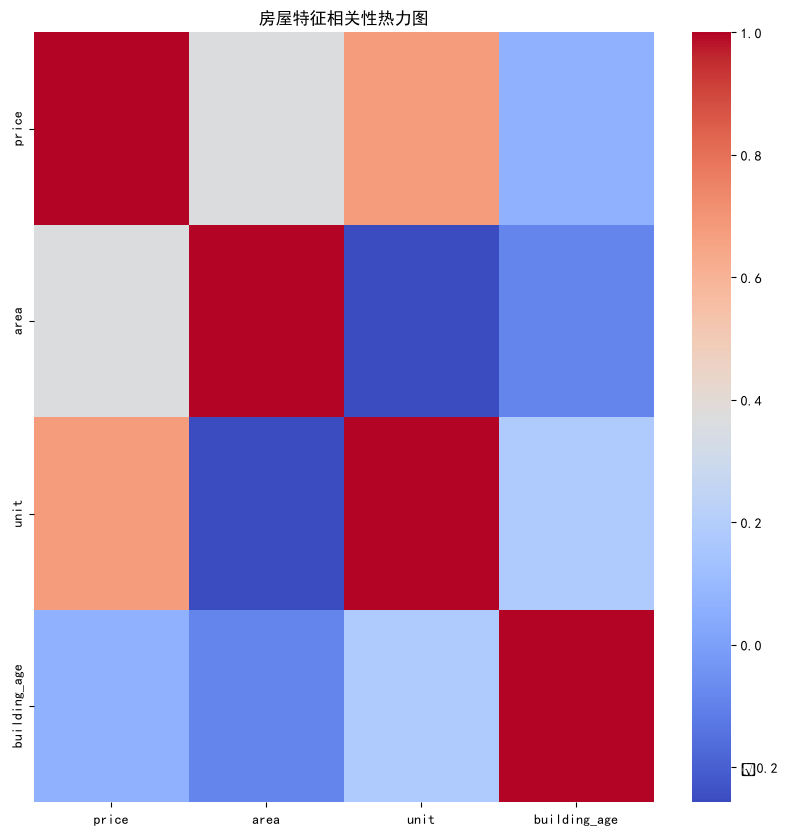

In [79]:
# 选择数值类型进行相关性分析
a = df[['price','area','unit','building_age']].corr()
df.head()
#对放假进行相关性分析
a['price'].sort_values(ascending = False)[1:]
# 相关性热力图制作
plt.figure(figsize=(10,10))
sns.heatmap(a,cmap = 'coolwarm')
plt.title('房屋特征相关性热力图')

<Axes: xlabel='price', ylabel='Count'>

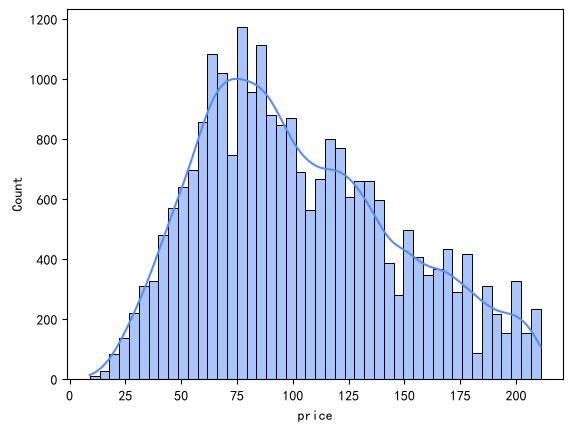

In [76]:
sns.histplot(data = df ,x = 'price',kde = True)

In [77]:
df['toward'].value_counts()
df.groupby('toward').agg({
    'price': ['mean', 'median'],
    'unit':  'median',
    'building_age': 'mean',
})

price            unit building_age
              mean median   median         mean
toward                                         
东北向      97.971075   95.0  10968.0    13.268817
东南向     103.823818   98.0  10333.0    11.836848
东向       94.378819   86.0  10577.0    13.711286
东西向      88.342759   79.0   8837.0    16.365517
北向       83.898776   75.0  11393.0    14.102041
南北向     104.637531   96.6   9390.5    12.891712
南向      101.528450   95.0  10173.0    12.452985
西北向     103.572810   90.0  12290.0    14.115702
西南向     121.336273  123.0  12671.0    14.290909
西向       93.095621   82.0  12381.0    14.241830

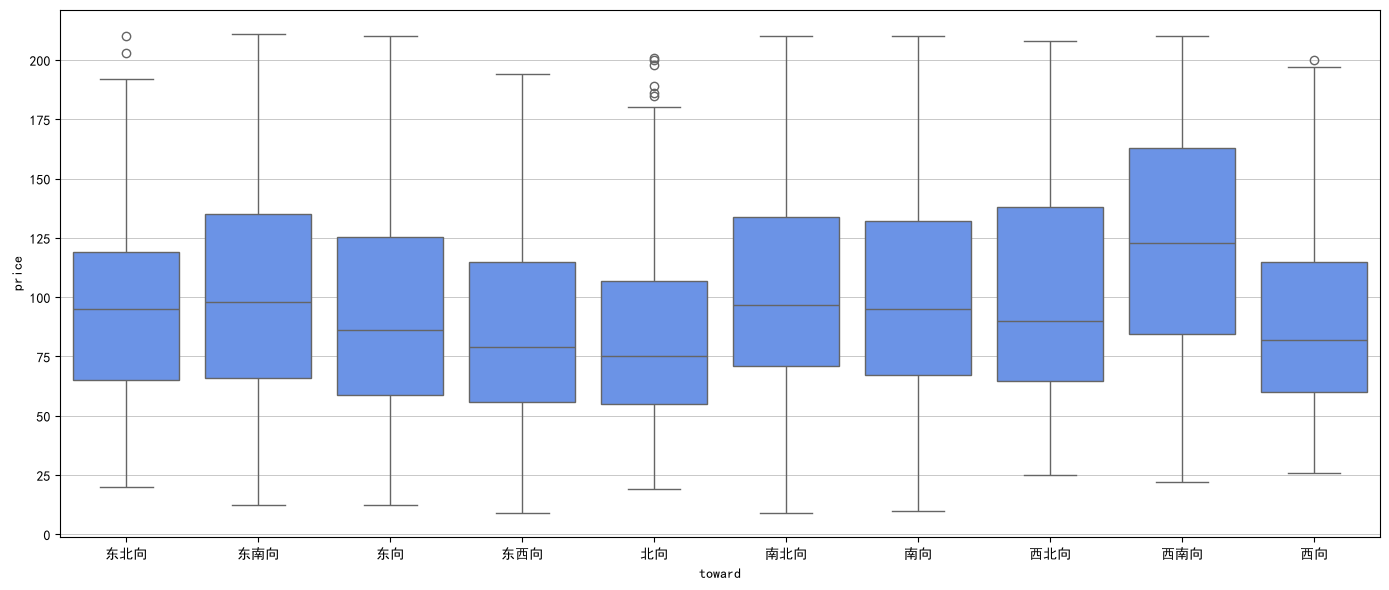

In [88]:
plt.figure(figsize=(14,6))
plt.grid(True,alpha=0.3,color = "black")
sns.boxplot(x = 'toward',y = 'price',data = df)
plt.tight_layout()